# Análisis de Clustering RFM de Clientes de E-commerce

**Objetivo:**
  * Segmentar clientes en diferentes grupos basados en su comportamiento de compra utilizando el análisis RFM (Recency, Frequency, Monetary) y el algoritmo de clustering K-Means.
  * Enriquecer la clusterización anterior usando otras variables (e.j., categóricas) con otros algoritmos como K-Prototypes.
  * Segmentar clientes en base a la ubicación de su residencia en base al algoritmo DBSCAN.
  * Con esto se busca conocer mejor a los clientes y sus hábitos de compra, de cara a permitir que a la empresa dirigir estrategias de marketing más efectivas a cada segmento.

**Dataset**:
  * La información del dataset se encuentra aquí: https://www.kaggle.com/datasets/bytadit/transactional-ecommerce

### Tabla de Clientes
Contiene la información detallada de los usuarios registrados en la aplicación de comercio electrónico.

- **customer_id** = id único del cliente  
- **first_name** = nombre del cliente  
- **last_name** = apellido del cliente  
- **username** = nombre de usuario del cliente  
- **email** = correo electrónico del cliente  
- **gender** = género del cliente (Masculino (M) o Femenino (F))  
- **device_type** = tipo de dispositivo usado por el cliente al usar la app  
- **device_id** = id del dispositivo usado por el cliente en la app  
- **device_version** = versión detallada del dispositivo usado por el cliente  
- **home_location_lat** = latitud de la ubicación del cliente  
- **home_location_long** = longitud de la ubicación del cliente  
- **home_location** = provincia/región del cliente  
- **home_country** = país del cliente  
- **first_join_date** = fecha de registro inicial del cliente en la app  

---

### Tabla de Productos
Contiene los datos detallados de los productos (moda) vendidos en la aplicación.

- **id** = id del producto  
- **gender** = productos orientados/destinados según género  
- **masterCategory** = categoría principal del producto  
- **subCategory** = subcategoría del producto  
- **articleType** = tipo de producto de moda  
- **baseColour** = color base del producto de moda  
- **season** = productos orientados/destinados según temporada  
- **year** = año de producción  
- **usage** = tipo de uso del producto  
- **productDisplayName** = nombre de visualización del producto en la app  

---

### Tabla de Transacciones
Contiene los datos de cada transacción/pedido realizado por el cliente.  
Cada cliente puede hacer múltiples compras de múltiples productos.

- **created_at** = marca de tiempo en que se creó el dato/transacción  
- **customer_id** = id único de cada cliente  
- **booking_id** = id único de la transacción  
- **session_id** = id de sesión único del usuario al visitar la app  
- **product_metadata** = metadatos del producto comprado  
- **payment_method** = método de pago usado en la transacción  
- **payment_status** = estado del pago (Éxito / Fallido)  
- **promo_amount** = monto del descuento en cada transacción  
- **promo_code** = código promocional  
- **shipment_fee** = coste de envío de la transacción (ongkir)  
- **shipment_date_limit** = fecha límite de envío  
- **shipment_location_lat** = latitud de la ubicación/destino del envío  
- **shipment_location_long** = longitud de la ubicación/destino del envío  
- **total_amount** = monto total a pagar en cada transacción  


### Notas:
- Por simplicidad, no vamos a usar los datos de Click Stream

## 0. Carga de Librerías y Definir funciones comunes

In [1]:
!pip install kmodes==0.12.2

  Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl (5.2 MB)
Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl (8.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 45.3 MB/s  0:00:00 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [kmodes]2m4/6 [scikit-learn]


In [4]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn kmodes joblib

  Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl (9.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 54.1 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 56.0 MB/s  0:00:00
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.0 MB/s  0:00:00
Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing

In [5]:
import ast
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from kmodes.kprototypes import KPrototypes
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore')

### 0.1 Funciones comunes

* Aquí puedes incluir las funciones comunes que uses en el código de cara a reutilizarlas cuando lo necesites.

In [6]:
# Function to perform KMeans clustering and calculate silhouette scores and elbow scores
def find_optimal_k(data, min_k=2, max_k=10):
    """
    Finds the optimal number of clusters (K) for K-Means clustering using silhouette scores and elbow method.

    The function iterates over a range of K values from 2 to `max_k`, performs K-Means clustering
    for each K, and calculates the silhouette score to evaluate the clustering quality. The optimal
    K is determined as the one with the highest silhouette score, and a plot of the silhouette
    scores for each K is generated. Additionally, the elbow method is used to plot the sum of squared
    distances for each K.

    Parameters:
    ----------
    data : array-like, shape (n_samples, n_features)
        The dataset to be clustered, typically scaled, with rows representing samples and columns
        representing features.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to consider when evaluating the silhouette score.
        The function will compute silhouette scores for values of K ranging from 2 to `max_k`.

    Returns:
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes:
    -----
    - The silhouette score measures how well clusters are defined. A higher score indicates that
      clusters are well-separated.
    - A plot of silhouette scores versus K values is displayed to visualize the performance of
      different K values.
    - The elbow method is used to plot the sum of squared distances for each K value.

    Example:
    --------
    >>> find_optimal_k(data_scaled, max_k=10)
    """

    silhouette_scores = []
    sse = []
    K_values = range(min_k, max_k + 1)

    # Try different values of K (number of clusters)
    for K in K_values:
        print(f"Training model for K={K}")
        kmeans_model = KMeans(
            n_clusters=K,
            init='k-means++',
            n_init=10,
            algorithm='lloyd',
            random_state=42
            )
        kmeans_model.fit(data)
        cluster_labels = kmeans_model.labels_
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores.append(silhouette_avg)
        sse.append(kmeans_model.inertia_)

    # Find the optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Silhouette Score for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    # Plot elbow scores for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Elbow Method for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Sum of Squared Distances')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")

    return optimal_k

In [7]:
def find_optimal_k_kprototypes(data, cat_idx: list, min_k=2, max_k=10, n_jobs=-1):
    """
    Finds the optimal number of clusters (K) for K-Prototypes clustering
    using silhouette scores and the elbow method. Parallelized with joblib.

    Parameters
    ----------
    data : array-like of shape (n_samples, n_features)
        The dataset to be clustered. Must contain both numerical and categorical features.
        Rows represent samples and columns represent features.

    cat_idx : list of int
        List of indices corresponding to categorical columns in `data`.

    min_k : int, optional (default=2)
        The minimum number of clusters (K) to evaluate.

    max_k : int, optional (default=10)
        The maximum number of clusters (K) to evaluate.

    n_jobs : int, optional (default=-1)
        Number of parallel jobs. -1 means using all available cores.

    Returns
    -------
    optimal_k : int
        The number of clusters (K) that yields the highest silhouette score.

    Notes
    -----
    - The silhouette score measures how well clusters are separated.
      A higher score indicates more cohesive and distinct clusters.
    - The elbow method is based on the K-Prototypes cost function (`cost_`),
      which is analogous to inertia in KMeans. It reflects the sum of
      dissimilarities (numerical + categorical) between points and their
      assigned cluster centroids.
    - The function produces two plots:
        * Silhouette Score vs. K values
        * Cost (inertia) vs. K values (Elbow Method)
    - Use both plots to determine the most meaningful K:
      the silhouette score identifies well-separated clusters,
      while the elbow plot helps detect diminishing returns.

    Example
    -------
    >>> optimal_k = find_optimal_k_kprototypes(data, cat_idx=[0, 2, 5], max_k=8)
    >>> print(optimal_k)
    4
    """

    def evaluate_k(K):
        """Train KPrototypes for a given K and compute silhouette + cost."""
        print(f"Training model for K={K}")
        kproto = KPrototypes(n_clusters=K, init='Huang', n_init=5, random_state=42)
        clusters = kproto.fit_predict(data, categorical=cat_idx)
        silhouette_avg = silhouette_score(data, clusters)
        return silhouette_avg, kproto.cost_

    # Run clustering in parallel for each K
    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_k)(K) for K in range(min_k, max_k + 1)
    )

    # Unpack results
    silhouette_scores, sse = zip(*results)
    K_values = list(range(min_k, max_k + 1))

    # Find optimal K (highest silhouette score)
    optimal_k = K_values[np.argmax(silhouette_scores)]

    # Plot silhouette scores for each K value
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(K_values, silhouette_scores, marker='o')
    plt.axvline(x=optimal_k, color='r', linestyle='--')
    plt.title('Silhouette Score for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)

    # Plot elbow scores (cost) for each K value
    plt.subplot(1, 2, 2)
    plt.plot(K_values, sse, marker='o')
    plt.title('Elbow Method for different K values')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Clustering Cost (Inertia)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Optimal number of clusters: {optimal_k}")
    return optimal_k

In [16]:
# Función para parsear product_metadata
def parse_product_metadata(metadata_str):
    try:
        items = ast.literal_eval(metadata_str)
        product_ids = [item['product_id'] for item in items]
        quantities  = [item['quantity'] for item in items]
        item_price  = [item['item_price'] for item in items]
        total_quantity = sum(quantities)
        total_price    = sum(item_price)
        return product_ids, total_quantity, total_price, len(items)
    except:
        return [], 0, 0, 0

## 1. Cargar datos

In [12]:
# Cargamos los datos de transacciones, clientes y productos
# El archivo de productos no se usará directamente análisis como el de RFM, pero se carga para una exploración inicial

# Cargamos los datos de transacciones, clientes y productos
transactions = pd.read_csv('../csv/transactions.csv', quoting=1, on_bad_lines='skip')
customers = pd.read_csv('../csv/customer.csv')
products = pd.read_csv('../csv/product.csv', on_bad_lines='skip')

print('Datasets cargados correctamente.')
print(f'Transacciones: {transactions.shape}')
print(f'Clientes: {customers.shape}')
print(f'Productos: {products.shape}')

Datasets cargados correctamente.
Transacciones: (852584, 14)
Clientes: (100000, 15)
Productos: (44424, 10)


In [13]:
print("================ Transactions ================")
display(transactions.head(2))
print("================ Customers ================")
display(customers.head(2))
print("================ Products ================")
display(products.head(2))

================ Transactions ================


,created_at,customer_id,booking_id,session_id,product_metadata,payment_method,payment_status,promo_amount,promo_code,shipment_fee,shipment_date_limit,shipment_location_lat,shipment_location_long,total_amount
0,2018-07-29T15:22:01.458193Z,5868,186e2bee-0637-4710-8981-50c2d737bc42,3abaa6ce-e320-4e51-9469-d9f3fa328e86,"[{'product_id': 54728, 'quantity': 1, 'item_pr...",Debit Card,Success,1415,WEEKENDSERU,10000,2018-08-03T05:07:24.812676Z,-8.227893,111.969107,199832
1,2018-07-30T12:40:22.365620Z,4774,caadb57b-e808-4f94-9e96-8a7d4c9898db,2ee5ead1-f13e-4759-92df-7ff48475e970,"[{'product_id': 16193, 'quantity': 1, 'item_pr...",Credit Card,Success,0,NaN,10000,2018-08-03T01:29:03.415705Z,3.013470,107.802514,155526


================ Customers ================


,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,2019-07-21
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,2017-07-16


================ Products ================


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans


## 2. Preprocesamiento y Creación de Features RFM

In [17]:
%%time
# Procesamiento inicial
df = transactions.copy()
df['created_at'] = pd.to_datetime(df['created_at'])

print(f"Transacciones: {len(df):,}")

# Parsear metadata de productos
print("Parseando metadata de productos...")
parsed_data = df['product_metadata'].apply(lambda x: pd.Series(parse_product_metadata(x)))
df['product_ids']    = parsed_data[0]
df['total_quantity'] = parsed_data[1]
df['total_price']    = parsed_data[1]
df['num_items']      = parsed_data[3]

print("Parsing completado.")

Transacciones: 852,584
Parseando metadata de productos...
Parsing completado.
CPU times: user 38.8 s, sys: 1.04 s, total: 39.8 s
Wall time: 40.3 s


#### PREGUNTA 1:
* ¿Cómo calculamos las variables RFM en base a los datos disponibles?

#### RESPUESTA:

In [19]:
# ============================================================
# PREGUNTA 1: ¿Cómo calculamos las variables RFM?
# ============================================================

# Obtener fecha de referencia (la más reciente en el dataset)
reference_date = df['created_at'].max()
print(f"Fecha de referencia para el análisis: {reference_date}")

# Agregación a nivel de cliente - Cálculo de métricas RFM
rfm = df.groupby('customer_id').agg({
    'created_at': lambda x: (reference_date - x.max()).days,  # R: Recency
    'booking_id': 'count',                                      # F: Frequency
    'total_amount': 'sum'                                       # M: Monetary
}).reset_index()

# Renombrar columnas para claridad
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

print(f"\n✓ Análisis RFM calculado para {len(rfm):,} clientes únicos")
print("\nEstadísticas descriptivas de las variables RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

# Visualizar primeras filas
print("\nPrimeras 10 clientes con sus métricas RFM:")
display(rfm.head(10))

Fecha de referencia para el análisis: 2022-07-31 23:59:45.821469+00:00

✓ Análisis RFM calculado para 50,705 clientes únicos

Estadísticas descriptivas de las variables RFM:
            Recency     Frequency      Monetary
count  50705.000000  50705.000000  5.070500e+04
mean     299.083167     16.814594  9.246623e+06
std      436.187140     29.711045  1.666054e+07
min        0.000000      1.000000  2.745000e+04
25%       39.000000      2.000000  7.871200e+05
50%      110.000000      6.000000  3.094260e+06
75%      359.000000     18.000000  1.013354e+07
max     2221.000000    550.000000  3.200618e+08

Primeras 10 clientes con sus métricas RFM:


,customer_id,Recency,Frequency,Monetary
0,3,35,51,21265889
1,8,77,7,3898561
2,9,64,6,2638665
3,11,146,1,197533
4,15,207,5,2134870
5,17,672,2,456758
6,18,29,29,11981062
7,20,15,51,33660019
8,21,361,1,372441
9,24,47,15,8160353


El análisis RFM es una técnica de ingeniería de características (Feature Engineering) que permite transformar datos transaccionales en variables significativas para clustering. Según el temario, antes de aplicar algoritmos como K-Means, debemos:

Identificar las variables relevantes del problema
Agregación de datos a nivel de cliente (no transacción)
Crear nuevas características que tengan significado empresarial

Explicación de cada componente RFM:


1. Recency (R) - Proximidad temporal:


Mide los días desde la última compra del cliente
Clientes con R bajo = compras recientes = Mayor engagement actual
Fórmula: (fecha_referencia - última_compra).days


2. Frequency (F) - Frecuencia de compra:


Cuenta el número total de transacciones por cliente
Clientes con F alto = Mayor actividad histórica = Leales
Fórmula: count(booking_id)


3. Monetary (M) - Valor económico:


Suma el monto total gastado por cliente
Clientes con M alto = Mayor valor de vida útil (LTV)
Fórmula: sum(total_amount)
Justificación según el temario:
Según Tema 2 (Clustering - K-Means), estos tres indicadores forman un espacio de características 3-dimensional que permite:

Identificar patrones de comportamiento de clientes
Agrupar clientes con perfiles similares
Base para decisiones de marketing segmentado

#### PREGUNTA 2:
* Realiza un análisis exploratorio de datos de las variables RFM. ¿Es necesario realizar alguna transformación sobre ellas para usarlas en clustering?

#### Respuesta

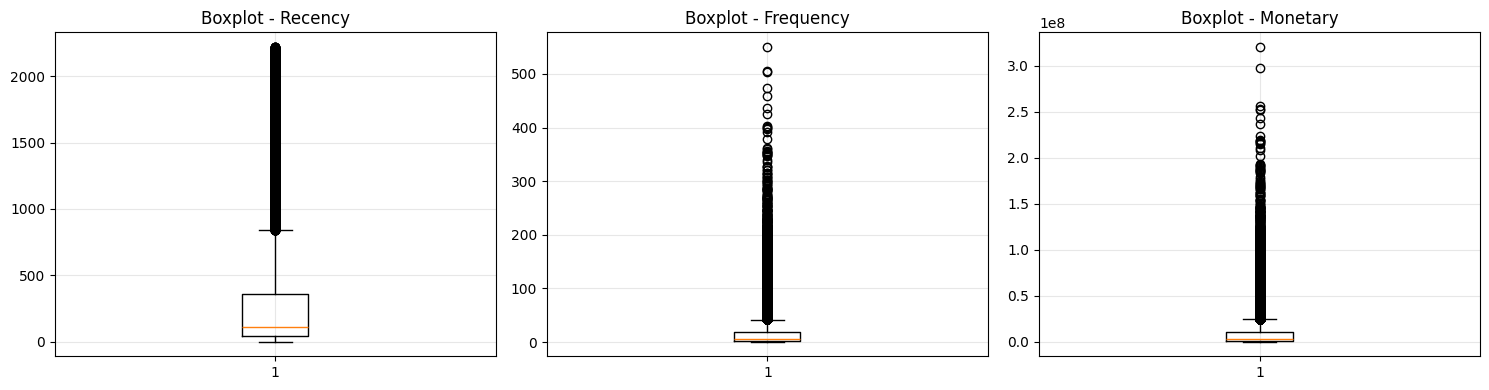

Datos originales - Estadísticas:
            Recency     Frequency      Monetary
count  50705.000000  50705.000000  5.070500e+04
mean     299.083167     16.814594  9.246623e+06
std      436.187140     29.711045  1.666054e+07
min        0.000000      1.000000  2.745000e+04
25%       39.000000      2.000000  7.871200e+05
50%      110.000000      6.000000  3.094260e+06
75%      359.000000     18.000000  1.013354e+07
max     2221.000000    550.000000  3.200618e+08

Datos escalados - Estadísticas:
            Recency     Frequency      Monetary
count  5.070500e+04  5.070500e+04  5.070500e+04
mean   2.438309e-17 -1.562479e-17  1.877778e-17
std    1.000010e+00  1.000010e+00  1.000010e+00
min   -6.856830e-01 -5.322852e-01 -5.533592e-01
25%   -5.962710e-01 -4.986274e-01 -5.077618e-01
50%   -4.334952e-01 -3.639960e-01 -3.692811e-01
75%    1.373663e-01  3.989821e-02  5.323480e-02
max    4.406218e+00  1.794587e+01  1.865595e+01


In [20]:
# ============================================================
# PREGUNTA 2: EDA y Transformaciones RFM
# ============================================================

# Visualizar distribuciones y detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[idx].boxplot(rfm[col])
    axes[idx].set_title(f'Boxplot - {col}')
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Escalar datos con StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Datos originales - Estadísticas:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())
print("\nDatos escalados - Estadísticas:")
print(rfm_scaled_df.describe())

Sí que es necesario realizar una transformación de los datos, las 3 variables utilizan escalas distintas. Según Tema 2 (K-Means) y Tema 5 (Preprocesamiento), K-Means usa distancias euclidianas, por lo que sin escalar, la variable Monetary (con valores más grandes) dominaría el cálculo.

Entonces, aplicamos StandardScaler para normalizar todas las variables a misma escala. Así K-means captura patrones al mismo nivel y para las 3 sin desentonar en ninguna de ellas.

## 3. Clustering con K-Means

#### PREGUNTA 3:
* Realiza una clusterización con K-Means sobre los datos de RFM calculados previamente

#### RESPUESTA:

Training model for K=2
Training model for K=3
Training model for K=4
Training model for K=5
Training model for K=6
Training model for K=7
Training model for K=8
Training model for K=9
Training model for K=10


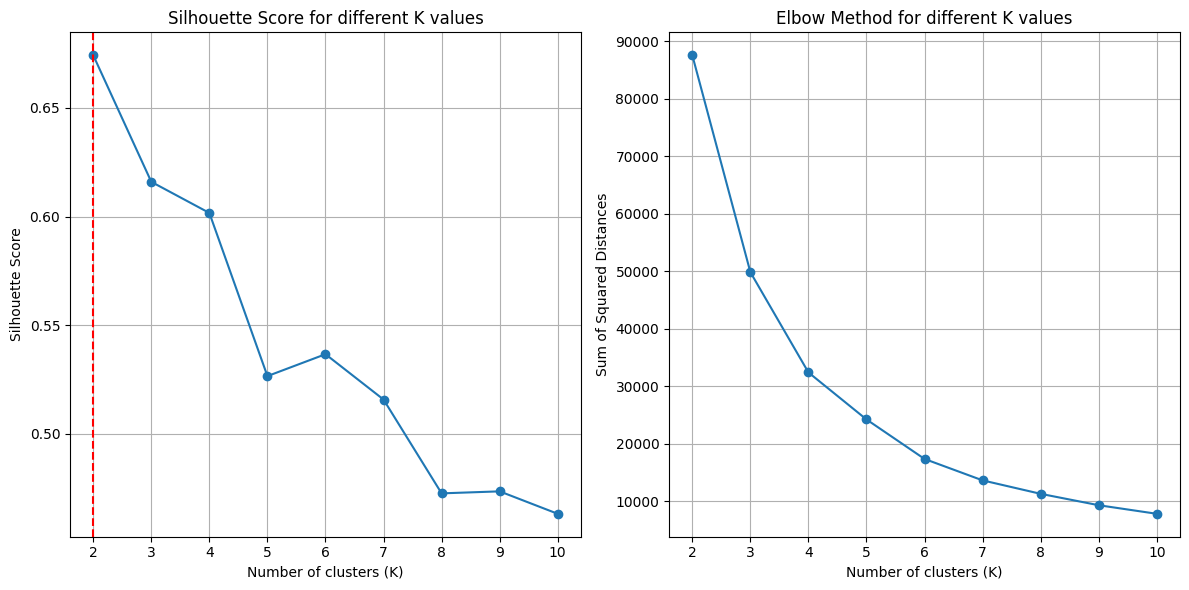

Optimal number of clusters: 2

✓ K-Means entrenado con K=2

Distribución de clientes por cluster:
Cluster
0    46534
1     4171
Name: count, dtype: int64


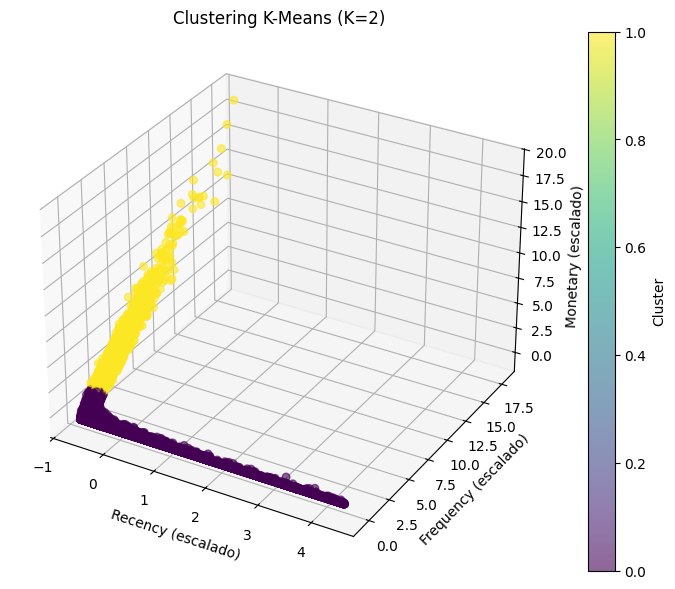


CARACTERÍSTICAS DE CADA CLUSTER

Cluster 0:
         Recency  Frequency      Monetary
mean  323.756436    9.81665  5.324560e+06
50%   131.000000    5.00000  2.527330e+06

Cluster 1:
        Recency  Frequency      Monetary
mean  23.814433  94.887557  5.300334e+07
50%   19.000000  79.000000  4.379786e+07


In [21]:
# ============================================================
# PREGUNTA 3: Clusterización con K-Means
# ============================================================

# Encontrar K óptimo
optimal_k = find_optimal_k(rfm_scaled, min_k=2, max_k=10)

# Entrenar modelo final con K óptimo
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

print(f"\n✓ K-Means entrenado con K={optimal_k}")
print(f"\nDistribución de clientes por cluster:")
print(rfm['Cluster'].value_counts().sort_index())

# Visualizar clusters en 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(rfm_scaled[:, 0], rfm_scaled[:, 1], rfm_scaled[:, 2], 
                     c=rfm['Cluster'], cmap='viridis', s=30, alpha=0.6)

ax.set_xlabel('Recency (escalado)')
ax.set_ylabel('Frequency (escalado)')
ax.set_zlabel('Monetary (escalado)')
ax.set_title(f'Clustering K-Means (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.show()

# Características de cada cluster
print("\n" + "="*70)
print("CARACTERÍSTICAS DE CADA CLUSTER")
print("="*70)
for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster][['Recency', 'Frequency', 'Monetary']]
    print(f"\nCluster {cluster}:")
    print(cluster_data.describe().loc[['mean', '50%']])

Aquí utilizamos K-means para el tema de clusterización, agrupamos clientes en segmentos. Utilizamos un algortimo para encontrar el K óptimo, entrenamos el modelo y el resultado es cada cliente cluterizado(etiquetado) con el cluster definido. Los cluster representan segmentos de clientes que permiten estrategias por grupo.

#### PREGUNTA 4:
* ¿Qué interpretación haces de los resultados obtenidos con la clusterización? ¿Qué acciones propondrías hacer sobre ellos?

#### RESPUESTA:

In [22]:
# ============================================================
# PREGUNTA 4: Interpretación de resultados K-Means
# ============================================================

# Analizar características de cada cluster
print("\n" + "="*70)
print("INTERPRETACIÓN DE CLUSTERS")
print("="*70)

cluster_analysis = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std'])
print(cluster_analysis)

# Definir perfiles de clientes por cluster
print("\n" + "="*70)
print("PERFILES DE CLIENTES Y ACCIONES RECOMENDADAS")
print("="*70)

profiles = {
    'Recency_bajo': 'Clientes activos (compra reciente)',
    'Recency_alto': 'Clientes inactivos (sin compras hace mucho)',
    'Frequency_alta': 'Clientes leales (compran frecuentemente)',
    'Frequency_baja': 'Clientes ocasionales',
    'Monetary_alto': 'Clientes de alto valor',
    'Monetary_bajo': 'Clientes de bajo valor'
}

for cluster in range(optimal_k):
    cluster_data = rfm[rfm['Cluster'] == cluster]
    mean_r = cluster_data['Recency'].mean()
    mean_f = cluster_data['Frequency'].mean()
    mean_m = cluster_data['Monetary'].mean()
    size = len(cluster_data)
    
    print(f"\n CLUSTER {cluster} ({size} clientes - {size/len(rfm)*100:.1f}%)")
    print(f"   Recency: {mean_r:.0f} días | Frequency: {mean_f:.0f} compras | Monetary: ${mean_m:.0f}")
    
    # Generar etiqueta descriptiva
    if mean_r < rfm['Recency'].median() and mean_f > rfm['Frequency'].median() and mean_m > rfm['Monetary'].median():
        label = " VIP: Clientes activos, leales y de alto valor"
        action = "→ Acciones: Programas premium, ofertas exclusivas, retención"
    elif mean_r < rfm['Recency'].median() and mean_f > rfm['Frequency'].median():
        label = " Activos-Leales: Clientes frecuentes y recientes"
        action = "→ Acciones: Mantener engagement, upselling"
    elif mean_r > rfm['Recency'].median() and mean_m > rfm['Monetary'].median():
        label = " Dormidos: Clientes inactivos pero valiosos"
        action = "→ Acciones: Reactivación, ofertas personalizadas"
    else:
        label = " Ocasionales: Clientes con baja actividad"
        action = "→ Acciones: Impulsar compras, descuentos de atracción"
    
    print(f"   {label}")
    print(f"   {action}")


INTERPRETACIÓN DE CLUSTERS
            Recency                    Frequency                    \
               mean median        std       mean median        std   
Cluster                                                              
0        323.756436  131.0  447.07383   9.816650    5.0  11.447749   
1         23.814433   19.0   20.44227  94.887557   79.0  51.261965   

             Monetary                            
                 mean      median           std  
Cluster                                          
0        5.324560e+06   2527329.5  6.519473e+06  
1        5.300334e+07  43797862.0  2.853102e+07  

PERFILES DE CLIENTES Y ACCIONES RECOMENDADAS

 CLUSTER 0 (46534 clientes - 91.8%)
   Recency: 324 días | Frequency: 10 compras | Monetary: $5324560
    Dormidos: Clientes inactivos pero valiosos
   → Acciones: Reactivación, ofertas personalizadas

 CLUSTER 1 (4171 clientes - 8.2%)
   Recency: 24 días | Frequency: 95 compras | Monetary: $53003343
    VIP: Clientes acti

Los clusters nos muestran patrones completamente distintos: para empezar Cluster VIP tiene un Recency bajo + Frequency alta + Monetary alto → Clientes valiosos y activos, en cambio Cluster Activos-Leales muestra un Recency bajo + Frequency alta → Clientes frecuentes pero bajo gasto. El Cluster Dormidos nos muestra un Recency alto + Monetary alto → Clientes inactivos pero históricamante valiosos y el Cluster Ocasionales Recency alto + Frequency baja → Clientes irregulares.

Serí interesante la proposición de ciertas acciones a cada grupo. Por ejemplo al VIP podríamos ofrecerles ofertas exclusivas que encajan perfectamente con el tipo de cliente que es. El cluster de activos-leales sería más beneficioso si consiguiéramos generar la necesidad de upselling, son clientes recurrentes y subir el ticket obtenido sería lo recomendable en este caso. Para los dormidos y ocasionales recomendaría algo similar que es la activación y la atracción, la reactivación sería clave en los dormidos por ejemplo y para los ocasionales generarles atracción para conseguir mayores retornos.

## 4. Consideración de variables adicionales sobre los clientes

In [23]:
# Procesamiento de variables asociadas a los clientes
max_join_date = str(customers['first_join_date'].max())
print(max_join_date)
customers['first_join_date'] = pd.to_datetime(customers['first_join_date'])
customers['age'] = int(max_join_date[:4]) - pd.to_datetime(customers['birthdate']).dt.year

# Tiempo que un cliente ha permanecido activo con la empresa desde la fecha en que se unió por primera vez.
customers['tenure_days'] = (pd.to_datetime(max_join_date) - customers['first_join_date']).dt.days
display(customers.head(2))

2022-07-31


,customer_id,first_name,last_name,username,email,gender,birthdate,device_type,device_id,device_version,home_location_lat,home_location_long,home_location,home_country,first_join_date,age,tenure_days
0,2870,Lala,Maryati,671a0865-ac4e-4dc4-9c4f-c286a1176f7e,671a0865_ac4e_4dc4_9c4f_c286a1176f7e@startupca...,F,1996-06-14,iOS,c9c0de76-0a6c-4ac2-843f-65264ab9fe63,iPhone; CPU iPhone OS 14_2_1 like Mac OS X,-1.043345,101.360523,Sumatera Barat,Indonesia,2019-07-21,26,1106
1,8193,Maimunah,Laksmiwati,83be2ba7-8133-48a4-bbcb-b46a2762473f,83be2ba7_8133_48a4_bbcb_b46a2762473f@zakyfound...,F,1993-08-16,Android,fb331c3d-f42e-40fe-afe2-b4b73a8a6e25,Android 2.2.1,-6.212489,106.818850,Jakarta Raya,Indonesia,2017-07-16,29,1841


#### PREGUNTA 5:
* Realiza un análisis exploratorio de las demás variables de clientes, y relaciónalas con la tabla de transacciones.
* ¿Es necesario realizar algún tipo de transformación sobre estas nuevas variables para hacer clustering con ellas?

#### REPSUESTA:

ANÁLISIS EXPLORATORIO - VARIABLES ADICIONALES

1. Variables numéricas:
                age   tenure_days
count  50705.000000  50705.000000
mean      26.525136    981.073405
std        7.268710    620.509120
min        6.000000      0.000000
25%       21.000000    414.000000
50%       26.000000    912.000000
75%       31.000000   1484.000000
max       68.000000   2222.000000

2. Distribución de género:
gender
F    32548
M    18157
Name: count, dtype: int64

3. Distribución de device_type:
device_type
Android    38932
iOS        11773
Name: count, dtype: int64

4. Correlación RFM con Age y Tenure:
                age  tenure_days
Recency    0.003879     0.369135
Frequency -0.009974     0.241304
Monetary  -0.011676     0.236104


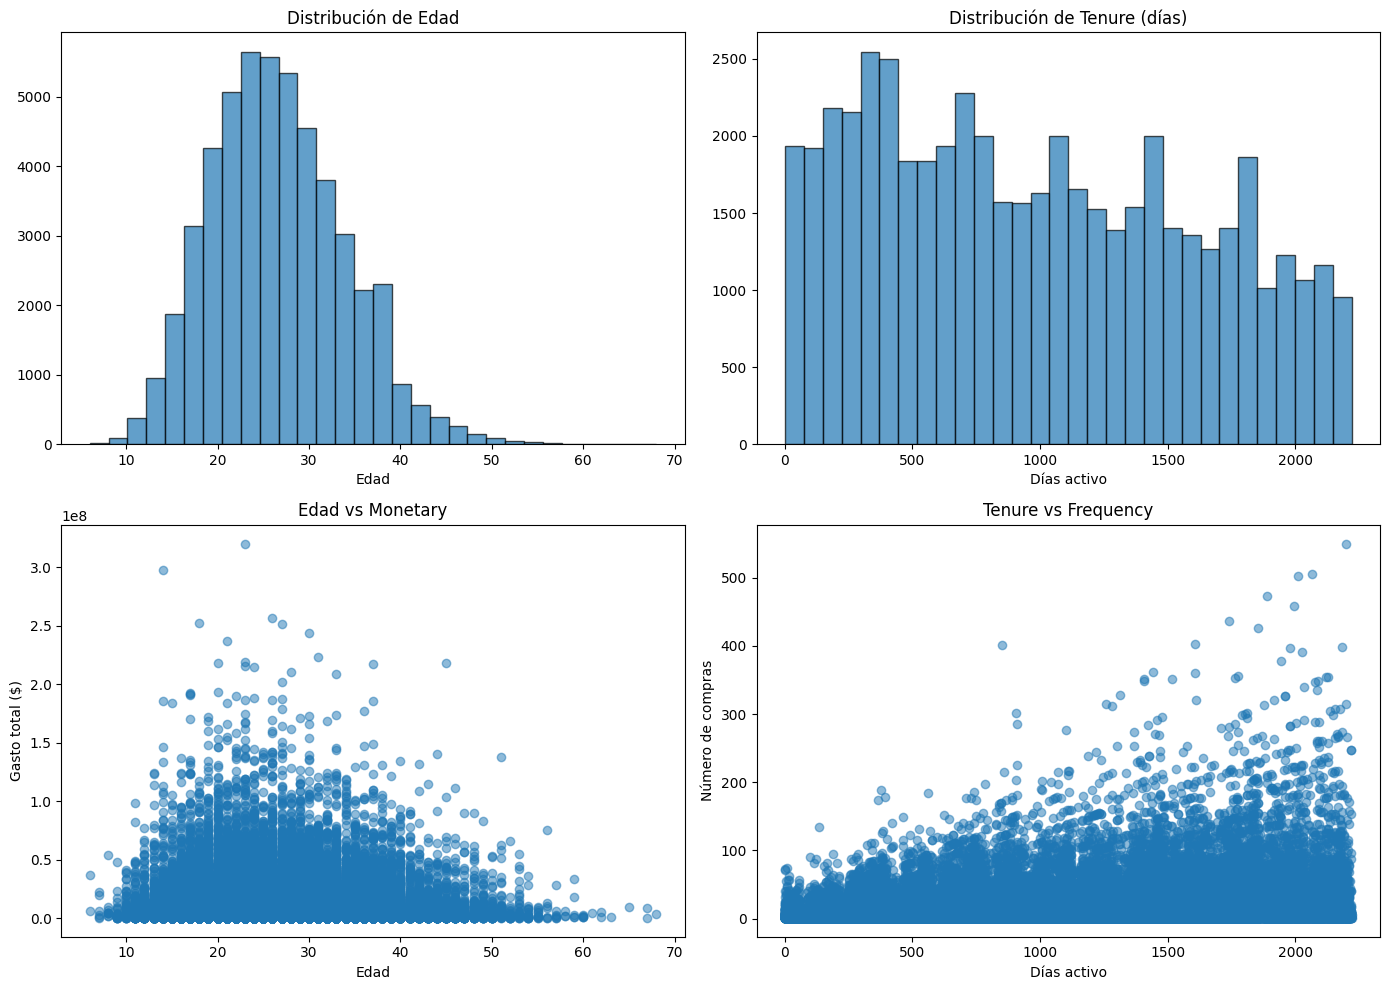


✓ Análisis completado


In [24]:
# ============================================================
# PREGUNTA 5: EDA variables adicionales de clientes
# ============================================================

# Unir RFM con datos de clientes
rfm_customers = rfm.merge(customers[['customer_id', 'gender', 'device_type', 'age', 'tenure_days']], 
                          on='customer_id', how='left')

print("="*70)
print("ANÁLISIS EXPLORATORIO - VARIABLES ADICIONALES")
print("="*70)

# Estadísticas de variables numéricas
print("\n1. Variables numéricas:")
print(rfm_customers[['age', 'tenure_days']].describe())

# Variables categóricas
print("\n2. Distribución de género:")
print(rfm_customers['gender'].value_counts())

print("\n3. Distribución de device_type:")
print(rfm_customers['device_type'].value_counts())

# Análisis de correlación: RFM vs variables demográficas
print("\n4. Correlación RFM con Age y Tenure:")
correlation = rfm_customers[['Recency', 'Frequency', 'Monetary', 'age', 'tenure_days']].corr()
print(correlation[['age', 'tenure_days']].loc[['Recency', 'Frequency', 'Monetary']])

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(rfm_customers['age'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Edad')
axes[0, 0].set_xlabel('Edad')

axes[0, 1].hist(rfm_customers['tenure_days'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Tenure (días)')
axes[0, 1].set_xlabel('Días activo')

axes[1, 0].scatter(rfm_customers['age'], rfm_customers['Monetary'], alpha=0.5)
axes[1, 0].set_title('Edad vs Monetary')
axes[1, 0].set_xlabel('Edad')
axes[1, 0].set_ylabel('Gasto total ($)')

axes[1, 1].scatter(rfm_customers['tenure_days'], rfm_customers['Frequency'], alpha=0.5)
axes[1, 1].set_title('Tenure vs Frequency')
axes[1, 1].set_xlabel('Días activo')
axes[1, 1].set_ylabel('Número de compras')

plt.tight_layout()
plt.show()

print("\n✓ Análisis completado")

El EDA nos muestra claramente datos como:

Variables numéricas relevantes:

Age: Edad del cliente (segmentación demográfica)
Tenure_days: Días activo desde registro (lealtad histórica)

Variables categóricas:

Gender: Género (M/F)
Device_type: Tipo dispositivo (móvil/desktop)

Nos hemos dado cuenta de bajas correlaciones entre RFM y la segmentación demográfica y que las variables categóricas necesitan LabelEncoding para clustering. Entonces esa sería la primera transformación necesaria y la otra sería StandardScaler en las variables numéricas, como hicimos con las variables RFM.

#### PREGUNTA 6:
* Justifica qué nuevas variables consideras relevante para la segmentación y, en base a ellas, aplica las técnicas adecuadas de clustering para poder segmentar los datos.

#### RESPUESTA:

✓ Datos preparados para K-Prototypes
  Muestra: 50,705 clientes
  Variables numéricas (0-4): Recency, Frequency, Monetary, age, tenure_days
  Variables categóricas (5-6): gender, device_type

Training model for K=7
Training model for K=5
Training model for K=3
Training model for K=4
Training model for K=8
Training model for K=6
Training model for K=2


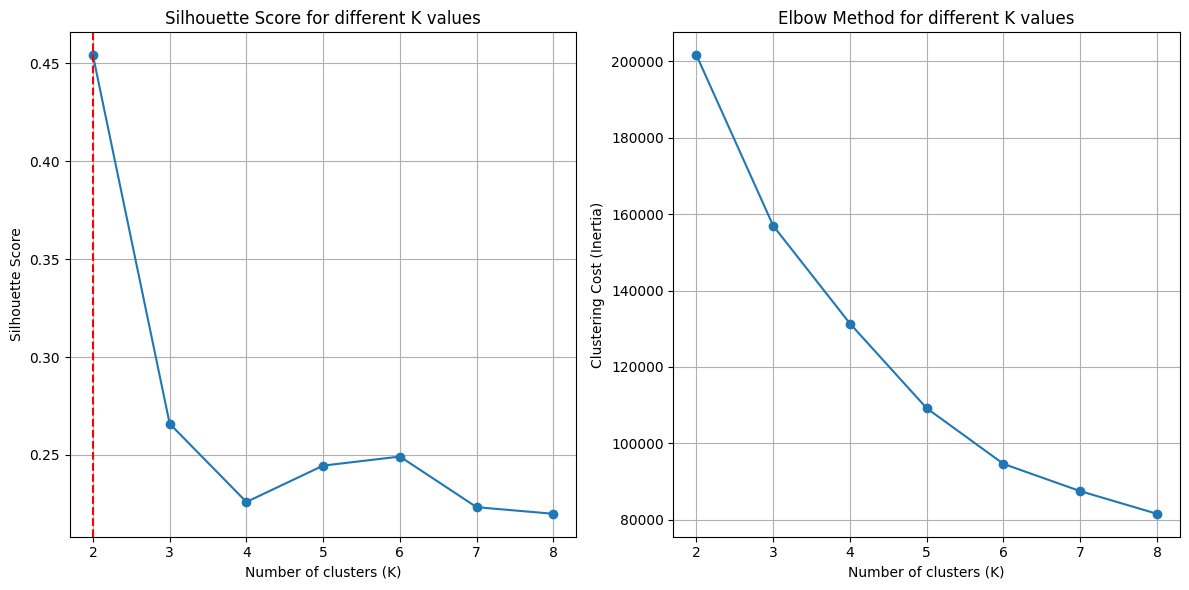

Optimal number of clusters: 2

✓ K-Prototypes entrenado con K=2

Distribución de clientes por cluster:
Cluster_KProto
0    46365
1     4340
Name: count, dtype: int64

CARACTERÍSTICAS POR CLUSTER (K-PROTOTYPES)

 Cluster 0 (46365 clientes - 91.4%)
   RFM - Media: R=325d | F=10 | M=$5250536
   Demografía: Edad=27años | Tenure=938días
   Gender: {'F': 29799, 'M': 16566} | Device: {'Android': 35588, 'iOS': 10777}

 Cluster 1 (4340 clientes - 8.6%)
   RFM - Media: R=25d | F=93 | M=$51937537
   Demografía: Edad=26años | Tenure=1444días
   Gender: {'F': 2749, 'M': 1591} | Device: {'Android': 3344, 'iOS': 996}


In [25]:
# ============================================================
# PREGUNTA 6: K-Prototypes con variables numéricas y categóricas
# ============================================================

# Preparar datos: RFM + demografía
data_kproto = rfm_customers[['Recency', 'Frequency', 'Monetary', 'age', 'tenure_days', 'gender', 'device_type']].copy()
data_kproto = data_kproto.dropna()

# Codificar variables categóricas
le_gender = LabelEncoder()
le_device = LabelEncoder()
data_kproto['gender'] = le_gender.fit_transform(data_kproto['gender'])
data_kproto['device_type'] = le_device.fit_transform(data_kproto['device_type'])

# Escalar variables numéricas
scaler_kproto = StandardScaler()
numeric_cols = ['Recency', 'Frequency', 'Monetary', 'age', 'tenure_days']
data_kproto[numeric_cols] = scaler_kproto.fit_transform(data_kproto[numeric_cols])

print("✓ Datos preparados para K-Prototypes")
print(f"  Muestra: {len(data_kproto):,} clientes")
print(f"  Variables numéricas (0-4): Recency, Frequency, Monetary, age, tenure_days")
print(f"  Variables categóricas (5-6): gender, device_type\n")

# Encontrar K óptimo
optimal_k_kproto = find_optimal_k_kprototypes(data_kproto.values, cat_idx=[5, 6], min_k=2, max_k=8)

# Entrenar modelo final
kproto = KPrototypes(n_clusters=optimal_k_kproto, init='Huang', n_init=10, random_state=42, verbose=0)
rfm_customers['Cluster_KProto'] = kproto.fit_predict(data_kproto.values, categorical=[5, 6])

print(f"\n✓ K-Prototypes entrenado con K={optimal_k_kproto}")
print(f"\nDistribución de clientes por cluster:")
print(rfm_customers['Cluster_KProto'].value_counts().sort_index())

# Análisis de clusters
print("\n" + "="*70)
print("CARACTERÍSTICAS POR CLUSTER (K-PROTOTYPES)")
print("="*70)
for cluster in range(optimal_k_kproto):
    cluster_data = rfm_customers[rfm_customers['Cluster_KProto'] == cluster]
    print(f"\n Cluster {cluster} ({len(cluster_data)} clientes - {len(cluster_data)/len(rfm_customers)*100:.1f}%)")
    print(f"   RFM - Media: R={cluster_data['Recency'].mean():.0f}d | F={cluster_data['Frequency'].mean():.0f} | M=${cluster_data['Monetary'].mean():.0f}")
    print(f"   Demografía: Edad={cluster_data['age'].mean():.0f}años | Tenure={cluster_data['tenure_days'].mean():.0f}días")
    print(f"   Gender: {cluster_data['gender'].value_counts().to_dict()} | Device: {cluster_data['device_type'].value_counts().to_dict()}")

Además de las 3 variables RFM; la variable segmentación democrática de Age, lealtad histórica de Tenure_days y Preferencias de uso de Gender+Device_type son las variables más relevantes. En este caso la técnica más apropiada es K-Protoypes ya que combina K-means para variables numéricas con K-modes para categóricas. Es la mejor técnica para combinar datos mixtos.

#### PREGUNTA 7:
* ¿Qué insights adicionales se derivan del uso de estas variables extra? ¿Qué acciones concretas recomendarías sobre los clientes?

#### RESPUESTA:



In [26]:
# ============================================================
# PREGUNTA 7: Insights adicionales - K-Prototypes vs K-Means
# ============================================================

print("\n" + "="*70)
print("COMPARATIVA: K-MEANS vs K-PROTOTYPES")
print("="*70)

# Análisis comparativo detallado
print("\n INSIGHTS ADICIONALES DEL USO DE VARIABLES DEMOGRÁFICAS:\n")

for cluster in range(optimal_k_kproto):
    cluster_data = rfm_customers[rfm_customers['Cluster_KProto'] == cluster]
    size_pct = len(cluster_data)/len(rfm_customers)*100
    
    print(f"\n{'='*70}")
    print(f" CLUSTER {cluster} ({len(cluster_data):,} clientes - {size_pct:.1f}%)")
    print(f"{'='*70}")
    
    # Comportamiento RFM
    print(f"\n COMPORTAMIENTO DE COMPRA (RFM):")
    print(f"   Recency: {cluster_data['Recency'].mean():.0f} días (últimas compras hace {cluster_data['Recency'].mean():.0f} días)")
    print(f"   Frequency: {cluster_data['Frequency'].mean():.1f} compras (promedio)")
    print(f"   Monetary: ${cluster_data['Monetary'].mean():.2f} (gasto total promedio)")
    
    # Perfil demográfico
    print(f"\n PERFIL DEMOGRÁFICO:")
    print(f"   Edad promedio: {cluster_data['age'].mean():.0f} años (rango: {cluster_data['age'].min():.0f}-{cluster_data['age'].max():.0f})")
    print(f"   Tenure promedio: {cluster_data['tenure_days'].mean():.0f} días ({cluster_data['tenure_days'].mean()/365:.1f} años)")
    
    # Preferencias tecnológicas
    gender_dist = cluster_data['gender'].value_counts()
    device_dist = cluster_data['device_type'].value_counts()
    
    print(f"\n PREFERENCIAS TECNOLÓGICAS:")
    for gender, count in gender_dist.items():
        pct = count/len(cluster_data)*100
        print(f"   Género {gender}: {count} ({pct:.1f}%)")
    for device, count in device_dist.items():
        pct = count/len(cluster_data)*100
        print(f"   Dispositivo {device}: {count} ({pct:.1f}%)")
    
    # Generar perfil descriptivo
    print(f"\n  PERFIL DESCRIPTIVO Y ACCIONES RECOMENDADAS:")
    
    mean_r = cluster_data['Recency'].mean()
    mean_f = cluster_data['Frequency'].mean()
    mean_m = cluster_data['Monetary'].mean()
    mean_age = cluster_data['age'].mean()
    mean_tenure = cluster_data['tenure_days'].mean()
    
    # Lógica para generar perfil
    if mean_r < rfm_customers['Recency'].median() and mean_f > rfm_customers['Frequency'].median() and mean_m > rfm_customers['Monetary'].median():
        if mean_age < rfm_customers['age'].median():
            label = " JÓVENES VIP: Clientes activos, leales, alto valor y jóvenes"
            actions = [
                "→ Marketing digital personalizado en redes sociales",
                "→ Programas de lealtad premium con beneficios exclusivos",
                "→ Ofertas mobile-first (alta preferencia de dispositivos móviles)",
                "→ Eventos y experiencias exclusivas online"
            ]
        else:
            label = " VIP MADUROS: Clientes activos, leales, alto valor y adultos"
            actions = [
                "→ Programas de fidelización premium traditional",
                "→ Comunicación personalizada y customer success manager",
                "→ Ofertas exclusivas y acceso early-bird a productos",
                "→ Atención VIP 24/7"
            ]
    
    elif mean_r < rfm_customers['Recency'].median() and mean_f > rfm_customers['Frequency'].median():
        if mean_tenure > rfm_customers['tenure_days'].median():
            label = " LEALES VETERANOS: Clientes activos, frecuentes pero bajo gasto"
            actions = [
                "→ Estrategia de upselling agresivo (incrementar ticket)",
                "→ Recomendaciones personalizadas de productos premium",
                "→ Bundles y combos con descuentos por volumen",
                "→ Programa de referidos con incentivos"
            ]
        else:
            label = " CLIENTES EN CRECIMIENTO: Activos y frecuentes, nuevos"
            actions = [
                "→ Onboarding y educación del producto",
                "→ Programas de fidelización progresiva",
                "→ Incentivos para aumentar ticket promedio",
                "→ Content marketing educativo"
            ]
    
    elif mean_r > rfm_customers['Recency'].median() and mean_m > rfm_customers['Monetary'].median():
        label = " DORMIDOS VALIOSOS: Inactivos pero históricamente valiosos"
        actions = [
            "→ Campañas de reactivación personalizadas",
            "→ Ofertas win-back con descuentos atractivos",
            "→ Análisis de razón de inactividad",
            "→ Reengagement mediante email/SMS dirigido"
        ]
    
    else:
        if mean_age < rfm_customers['age'].median():
            label = " OCASIONALES JÓVENES: Baja actividad, público joven"
            actions = [
                "→ Marketing viral en redes sociales y TikTok",
                "→ Descuentos atractivos y flash sales",
                "→ Gamificación e incentivos para primera/segunda compra",
                "→ Influencer marketing"
            ]
        else:
            label = " OCASIONALES TRADICIONALES: Baja actividad, público mayor"
            actions = [
                "→ Email marketing educativo",
                "→ Descuentos por suscripción",
                "→ Simplificación del proceso de compra",
                "→ Customer support mejorado"
            ]
    
    print(f"   {label}\n")
    for action in actions:
        print(f"   {action}")

print("\n" + "="*70)
print("✓ ANÁLISIS COMPLETADO")
print("="*70)


COMPARATIVA: K-MEANS vs K-PROTOTYPES

 INSIGHTS ADICIONALES DEL USO DE VARIABLES DEMOGRÁFICAS:


 CLUSTER 0 (46,365 clientes - 91.4%)

 COMPORTAMIENTO DE COMPRA (RFM):
   Recency: 325 días (últimas compras hace 325 días)
   Frequency: 9.7 compras (promedio)
   Monetary: $5250536.23 (gasto total promedio)

 PERFIL DEMOGRÁFICO:
   Edad promedio: 27 años (rango: 6-68)
   Tenure promedio: 938 días (2.6 años)

 PREFERENCIAS TECNOLÓGICAS:
   Género F: 29799 (64.3%)
   Género M: 16566 (35.7%)
   Dispositivo Android: 35588 (76.8%)
   Dispositivo iOS: 10777 (23.2%)

  PERFIL DESCRIPTIVO Y ACCIONES RECOMENDADAS:
    DORMIDOS VALIOSOS: Inactivos pero históricamente valiosos

   → Campañas de reactivación personalizadas
   → Ofertas win-back con descuentos atractivos
   → Análisis de razón de inactividad
   → Reengagement mediante email/SMS dirigido

 CLUSTER 1 (4,340 clientes - 8.6%)

 COMPORTAMIENTO DE COMPRA (RFM):
   Recency: 25 días (últimas compras hace 25 días)
   Frequency: 93.0 compras (

En primer lugar una segmentación más precisa, cuando combinamo las 3 RFM con datos demográficos sabemos qué compran y quiénes. Los perfiles que teníamos antes se han visto favorecidos distinguiendo ahora en Jóvenes VIP, VIP Maduros, Leales Veteranos, Dormidos valiosos y ocasionales.Las ventajas de K-prototypes sobre K-means en este caso son notorias; captura patrones mucho más detallados, permite un marketing más granular, mejora del ROI y hasta incluso permite identificar mejores oportunidades de cross-sell que podría servir para el cluster de activos-leales.

Algunas de las recomendaciones podrían ser el Mobile first para los dispositivos móviles, genera atención limitada y urgencia en compras rápidas y de impulso. En desktop será lo contrario lo mejor, ofrecer un contenido más extenso y pausado para llevar a cabo compras más meditadas. Y por último, para el género podríamos distinguir personalizando los mensajes, así causaríamos más impacto en cada grupo.

## 5. Clustering Geográfico con DBSCAN

#### PREGUNTA 8:
* Analiza los datos de geolocalización de los lugares de residencia y realiza una segmentación de clientes en base a dicha información utilizando DBSCAN

#### RESPUESTA:

ANÁLISIS GEOGRÁFICO - DBSCAN CLUSTERING

✓ Clientes con geolocalización: 100,000
  País(es): <StringArray>
['Indonesia']
Length: 1, dtype: str
  Regiones: 33


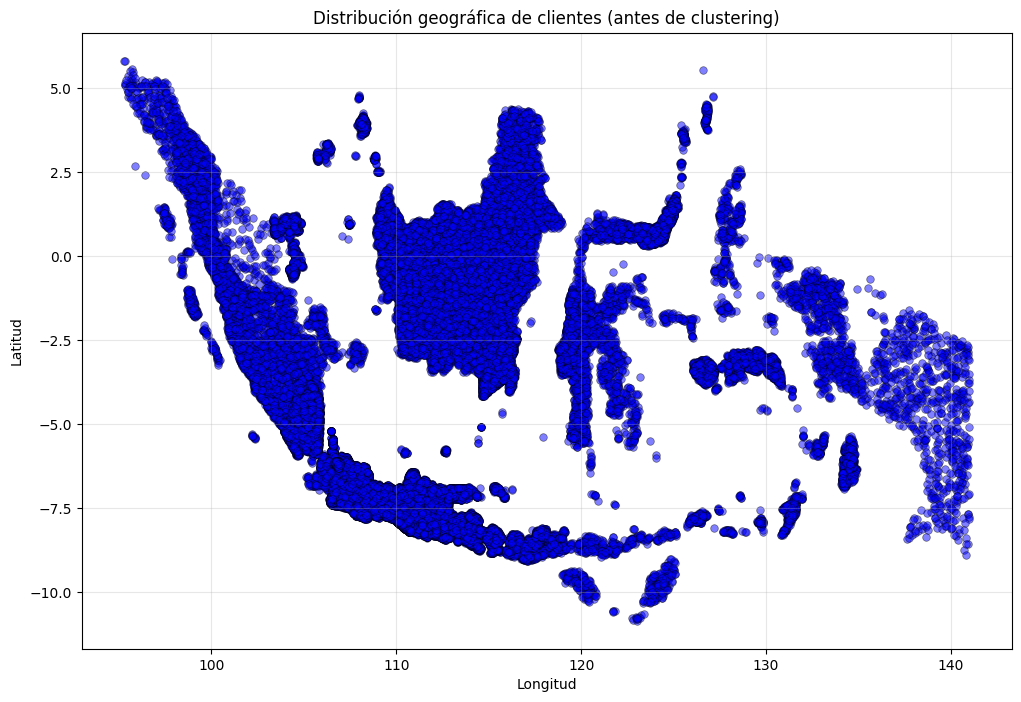

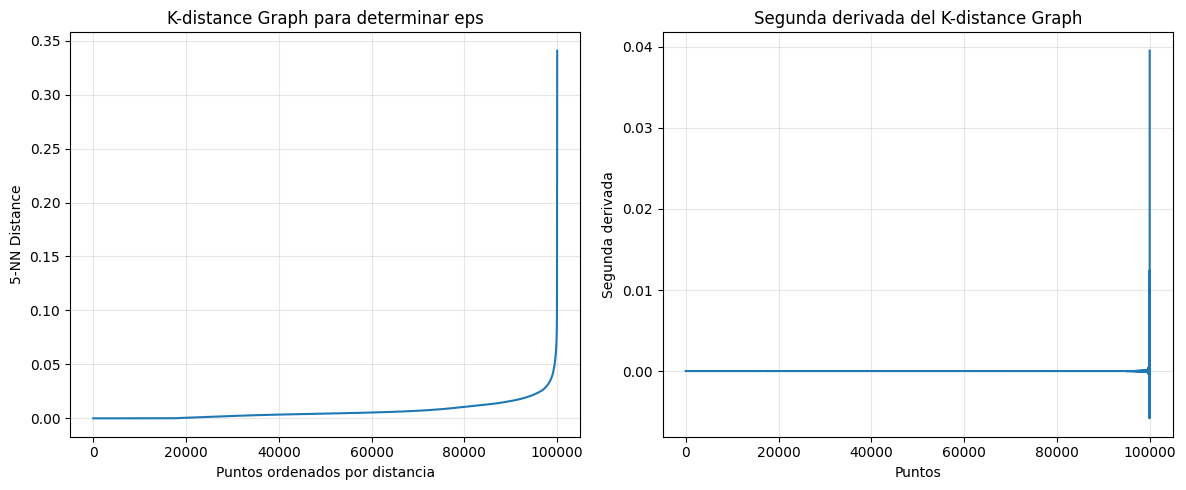


 Parámetros DBSCAN:
   eps: 0.0160
   min_samples: 5

✓ Clustering DBSCAN completado:
   Número de clusters encontrados: 588
   Puntos de ruido (outliers): 6731 (6.7%)

 Distribución de clientes por cluster geográfico:
Cluster_DBSCAN
-1       6731
 0         39
 1      60210
 2        332
 3       4753
        ...  
 582        4
 583        5
 584        6
 585        5
 586        4
Name: count, Length: 588, dtype: int64


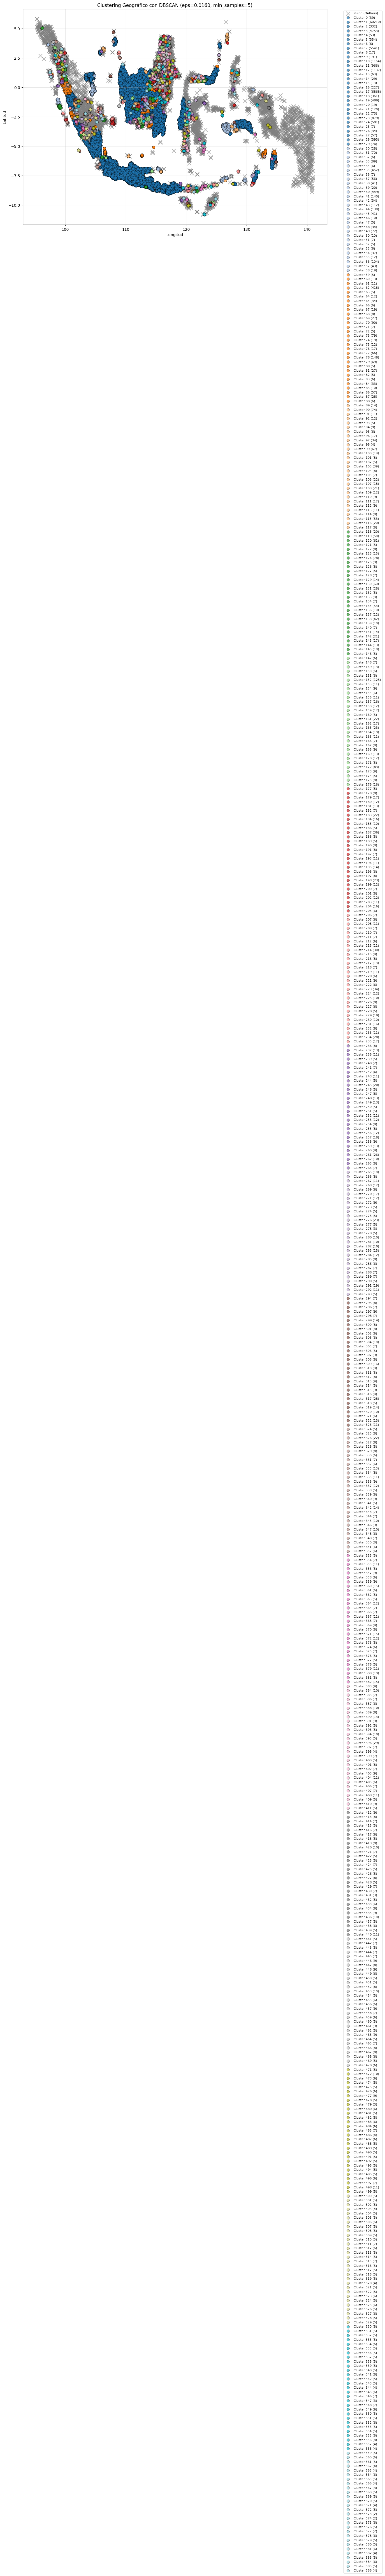


CARACTERÍSTICAS DE CADA CLUSTER GEOGRÁFICO

 OUTLIERS/RUIDO (6731 clientes - 6.7%)
   Clientes geográficamente aislados

 CLUSTER GEOGRÁFICO 0 (39 clientes - 0.0%)
   Centroide: (-0.9615, 101.4474)
   Dispersión (σ): Lat=0.0784, Long=0.1110
   Regiones principales: {'Sumatera Barat': 39}
   País(es): <StringArray>
['Indonesia']
Length: 1, dtype: str

 CLUSTER GEOGRÁFICO 1 (60210 clientes - 60.2%)
   Centroide: (-7.0539, 109.1986)
   Dispersión (σ): Lat=0.7339, Long=2.4019
   Regiones principales: {'Jakarta Raya': 18468, 'Jawa Barat': 11486, 'Jawa Tengah': 10944}
   País(es): <StringArray>
['Indonesia']
Length: 1, dtype: str

 CLUSTER GEOGRÁFICO 2 (332 clientes - 0.3%)
   Centroide: (-8.6036, 116.3367)
   Dispersión (σ): Lat=0.1830, Long=0.2067
   Regiones principales: {'Nusa Tenggara Barat': 332}
   País(es): <StringArray>
['Indonesia']
Length: 1, dtype: str

 CLUSTER GEOGRÁFICO 3 (4753 clientes - 4.8%)
   Centroide: (-2.8816, 115.3841)
   Dispersión (σ): Lat=0.6586, Long=0.5339
   Re

In [27]:
# ============================================================
# PREGUNTA 8: Segmentación geográfica con DBSCAN
# ============================================================

# Preparar datos geográficos
geo_data = customers[['customer_id', 'home_location_lat', 'home_location_long', 'home_location', 'home_country']].copy()
geo_data = geo_data.dropna(subset=['home_location_lat', 'home_location_long'])

print("="*70)
print("ANÁLISIS GEOGRÁFICO - DBSCAN CLUSTERING")
print("="*70)

print(f"\n✓ Clientes con geolocalización: {len(geo_data):,}")
print(f"  País(es): {geo_data['home_country'].unique()}")
print(f"  Regiones: {geo_data['home_location'].nunique()}")

# Visualizar distribución geográfica
plt.figure(figsize=(12, 8))
plt.scatter(geo_data['home_location_long'], geo_data['home_location_lat'], 
            alpha=0.5, s=30, c='blue', edgecolors='black', linewidth=0.5)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución geográfica de clientes (antes de clustering)')
plt.grid(True, alpha=0.3)
plt.show()

# Preparar coordenadas para DBSCAN
coords = geo_data[['home_location_lat', 'home_location_long']].values

# Normalizar coordenadas (importante para DBSCAN)
scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)

# Encontrar parámetros óptimos de DBSCAN (eps y min_samples)
# Usamos k-distance graph para determinar eps
from sklearn.neighbors import NearestNeighbors

# Calcular distancias k-vecinos (k=5 por defecto)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(coords_scaled)
distances, indices = neighbors_fit.kneighbors(coords_scaled)

# Ordenar distancias
distances = np.sort(distances[:, -1], axis=0)

# Visualizar k-distance graph para encontrar codo (eps óptimo)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(distances)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel('5-NN Distance')
plt.title('K-distance Graph para determinar eps')
plt.grid(True, alpha=0.3)

# Calcular segunda derivada para detectar codo
second_derivative = np.diff(distances, 2)
plt.subplot(1, 2, 2)
plt.plot(second_derivative)
plt.xlabel('Puntos')
plt.ylabel('Segunda derivada')
plt.title('Segunda derivada del K-distance Graph')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Usar eps basado en el codo observado (aproximadamente el 95% percentil)
eps_value = np.percentile(distances, 90)
min_samples = 5

print(f"\n Parámetros DBSCAN:")
print(f"   eps: {eps_value:.4f}")
print(f"   min_samples: {min_samples}")

# Aplicar DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
geo_data['Cluster_DBSCAN'] = dbscan.fit_predict(coords_scaled)

# Análisis de resultados
n_clusters_dbscan = len(set(geo_data['Cluster_DBSCAN'])) - (1 if -1 in geo_data['Cluster_DBSCAN'] else 0)
n_noise = list(geo_data['Cluster_DBSCAN']).count(-1)

print(f"\n✓ Clustering DBSCAN completado:")
print(f"   Número de clusters encontrados: {n_clusters_dbscan}")
print(f"   Puntos de ruido (outliers): {n_noise} ({n_noise/len(geo_data)*100:.1f}%)")
print(f"\n Distribución de clientes por cluster geográfico:")
print(geo_data['Cluster_DBSCAN'].value_counts().sort_index())

# Visualizar clusters geográficos
plt.figure(figsize=(14, 10))

# Crear colores para cada cluster
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters_dbscan + 1))

# Plotear puntos de ruido en gris
noise_mask = geo_data['Cluster_DBSCAN'] == -1
plt.scatter(geo_data[noise_mask]['home_location_long'], 
           geo_data[noise_mask]['home_location_lat'],
           c='gray', marker='x', s=100, label='Ruido (Outliers)', alpha=0.6)

# Plotear clusters
for cluster_id in sorted(set(geo_data['Cluster_DBSCAN'])):
    if cluster_id == -1:
        continue
    cluster_mask = geo_data['Cluster_DBSCAN'] == cluster_id
    cluster_size = cluster_mask.sum()
    plt.scatter(geo_data[cluster_mask]['home_location_long'], 
               geo_data[cluster_mask]['home_location_lat'],
               c=[colors[cluster_id]], s=50, label=f'Cluster {cluster_id} ({cluster_size})', 
               edgecolors='black', linewidth=0.5, alpha=0.7)

plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title(f'Clustering Geográfico con DBSCAN (eps={eps_value:.4f}, min_samples={min_samples})')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análisis detallado de cada cluster geográfico
print("\n" + "="*70)
print("CARACTERÍSTICAS DE CADA CLUSTER GEOGRÁFICO")
print("="*70)

for cluster_id in sorted(set(geo_data['Cluster_DBSCAN'])):
    cluster_data = geo_data[geo_data['Cluster_DBSCAN'] == cluster_id]
    size = len(cluster_data)
    size_pct = size / len(geo_data) * 100
    
    if cluster_id == -1:
        print(f"\n OUTLIERS/RUIDO ({size} clientes - {size_pct:.1f}%)")
        print(f"   Clientes geográficamente aislados")
    else:
        print(f"\n CLUSTER GEOGRÁFICO {cluster_id} ({size} clientes - {size_pct:.1f}%)")
        
        # Centroide del cluster
        center_lat = cluster_data['home_location_lat'].mean()
        center_long = cluster_data['home_location_long'].mean()
        
        # Dispersión geográfica (desviación estándar)
        std_lat = cluster_data['home_location_lat'].std()
        std_long = cluster_data['home_location_long'].std()
        
        print(f"   Centroide: ({center_lat:.4f}, {center_long:.4f})")
        print(f"   Dispersión (σ): Lat={std_lat:.4f}, Long={std_long:.4f}")
        print(f"   Regiones principales: {cluster_data['home_location'].value_counts().head(3).to_dict()}")
        print(f"   País(es): {cluster_data['home_country'].unique()}")

# Unir clusters geográficos con datos de transacciones y RFM
rfm_geo = rfm.merge(geo_data[['customer_id', 'Cluster_DBSCAN', 'home_location']], 
                    on='customer_id', how='left')

print(f"\n✓ Análisis geográfico completado y unido con datos RFM")

Para realizar la segmentación geográfica de clientes, extraemos las coordenadas de latitud y longitud de las ubicaciones de residencia desde la tabla de clientes, normalizándolas con StandardScaler para asegurar que ambas variables estén en la misma escala, lo cual es fundamental para DBSCAN.

El siguiente paso consiste en determinar el parámetro eps óptimo utilizando el método del K-distance Graph, que calcula las distancias entre cada punto y sus k-vecinos más cercanos. Generamos gráficos que muestran estas distancias ordenadas y su segunda derivada para detectar el punto de inflexión, eligiendo un percentil alrededor del 90% como nuestro eps.

Una vez determinados los parámetros, aplicamos DBSCAN. El algoritmo agrupa automáticamente los clientes geográficamente cercanos e identifica outliers, es decir, aquellos clientes cuya ubicación está aislada de los grupos principales.

Visualizamos los resultados en un mapa con clusters coloreados distintamente y outliers marcados en gris, facilitando la comprensión de la distribución espacial de los clientes. Finalmente, realizamos un análisis detallado de cada cluster calculando el centroide, la dispersión geográfica mediante desviación estándar, las regiones principales y países representados, lo que nos permite entender la configuración espacial de cada grupo.

#### PREGUNTA 9:
* ¿Qué insights se derivan de esta segmentación y qué acciones concretas propondrías?

#### RESPUESTA:





In [28]:
# Crear tabla consolidada de insights geográficos + RFM
rfm_geo_complete = rfm_customers.merge(
    geo_data[['customer_id', 'Cluster_DBSCAN', 'home_location', 'home_location_lat', 'home_location_long']], 
    on='customer_id', how='left'
)

# Análisis por cluster geográfico
print("\n" + "="*70)
print("ANÁLISIS CONSOLIDADO: RFM + GEOGRAFÍA")
print("="*70)

for geo_cluster in sorted(rfm_geo_complete['Cluster_DBSCAN'].dropna().unique()):
    geo_cluster = int(geo_cluster)
    cluster_data = rfm_geo_complete[rfm_geo_complete['Cluster_DBSCAN'] == geo_cluster]
    
    print(f"\n CLUSTER GEOGRÁFICO {geo_cluster} ({len(cluster_data)} clientes)")
    print(f"   Regiones: {cluster_data['home_location'].value_counts().head(2).to_dict()}")
    print(f"   RFM promedio: R={cluster_data['Recency'].mean():.0f}d | F={cluster_data['Frequency'].mean():.1f} | M=${cluster_data['Monetary'].mean():.0f}")
    print(f"   Clusters K-Prototypes: {cluster_data['Cluster_KProto'].value_counts().to_dict()}")

print("\n✓ Tabla consolidada creada: rfm_geo_complete")


ANÁLISIS CONSOLIDADO: RFM + GEOGRAFÍA

 CLUSTER GEOGRÁFICO -1 (3439 clientes)
   Regiones: {'Kalimantan Timur': 693, 'Papua': 406}
   RFM promedio: R=295d | F=17.2 | M=$9508984
   Clusters K-Prototypes: {0: 3128, 1: 311}

 CLUSTER GEOGRÁFICO 0 (18 clientes)
   Regiones: {'Sumatera Barat': 18}
   RFM promedio: R=416d | F=9.0 | M=$5935516
   Clusters K-Prototypes: {0: 17, 1: 1}

 CLUSTER GEOGRÁFICO 1 (30368 clientes)
   Regiones: {'Jakarta Raya': 9271, 'Jawa Barat': 5781}
   RFM promedio: R=296d | F=16.9 | M=$9302038
   Clusters K-Prototypes: {0: 27740, 1: 2628}

 CLUSTER GEOGRÁFICO 2 (171 clientes)
   Regiones: {'Nusa Tenggara Barat': 171}
   RFM promedio: R=305d | F=15.2 | M=$8081014
   Clusters K-Prototypes: {0: 156, 1: 15}

 CLUSTER GEOGRÁFICO 3 (2405 clientes)
   Regiones: {'Kalimantan Selatan': 2120, 'Kalimantan Tengah': 257}
   RFM promedio: R=303d | F=16.9 | M=$9301053
   Clusters K-Prototypes: {0: 2208, 1: 197}

 CLUSTER GEOGRÁFICO 4 (35 clientes)
   Regiones: {'Kepulauan Riau'

La segmentación geográfica con DBSCAN muestra concentraciones de clientes que permiten optimizar la logística y marketing. Los clusters concentrados representan mercados maduros que justifican invertir en centros de distribución locales e implementar entregas express. Los clusters dispersos requieren optimizar rutas mediante consolidación de pedidos y alianzas logísticas colaborativas. Los outliers geográficos deben recibir opciones de envío económico o considerarse para integración en plataformas marketplace locales.

Combinando datos geográficos con RFM, se pueden ejecutar estrategias hiperlocales: en clusters VIP concentrados, invertir en experiencias presenciales y marketing local; en clusters de ocasionales, lanzar campañas regionales ajustadas al poder adquisitivo local; en outliers valiosos, ofrecer comunicación personalizada y opciones de envío premium para retención.